<h1><center>EIE401 - PROCESAMIENTO DIGITAL MULTIMEDIA</center></h1>
<h2><center>Proyecto 2: Detección y medición de objetos astronómicos en imágenes ruidosas</center></h2>
<center><h3>Profesor: Jorge Cárdenas</h3></center>
<center><h3>Estudiante: Javiera Vega Pino</h3></center>
<center><h5>Pontificia Universidad Católica de Valparaíso</h5></center>

In [ ]:
from IPython.display import IFrame, display
filepath = "Proyecto_2_EIE401_Astronomia_ES.pdf"
IFrame(filepath, width=760, height=520)


## Instrucciones generales

En este proyecto debes construir un pipeline clásico de procesamiento de imágenes para detectar y medir objetos astronómicos en imágenes ruidosas. No debes usar redes neuronales, modelos preentrenados, clasificadores de aprendizaje automático, PyTorch ni TensorFlow.

Debes reportar obligatoriamente:

1. Error de conteo por imagen:

$$E_N = |N_{\mathrm{pred}} - N_{\mathrm{true}}|$$

2. Error de centroide para objetos emparejados:

$$e_c^{(i)} = \sqrt{(x_i-\hat{x}_i)^2 + (y_i-\hat{y}_i)^2}$$

Incluye hasta 10 ejemplos visuales representativos: detecciones correctas, falsos positivos y falsos negativos. No es necesario entregar una carpeta separada con imágenes procesadas ni un catálogo final en formato CSV; las métricas y ejemplos deben quedar claramente visibles en el notebook y en el informe.

## Presentación oral de 15 minutos

Además del notebook y del informe, deben preparar una presentación oral de **15 minutos** sobre el proceso desarrollado y los resultados obtenidos.

La presentación debe incluir:

1. Descripción breve del problema y del conjunto de imágenes.
2. Diagrama o resumen del flujo de procesamiento implementado.
3. Explicación de las etapas principales: filtrado, estimación de fondo, realce, segmentación, morfología y componentes conectados.
4. Resultados cuantitativos usando, al menos, el error de conteo $E_N$ y el error de centroide.
5. Ejemplos visuales de detecciones correctas, falsos positivos y falsos negativos.
6. Discusión breve sobre las limitaciones del método y posibles mejoras.

Las métricas mostradas en la presentación deben coincidir con las reportadas en el notebook y en el informe final.


## 0. Generación o carga del dataset

Puedes generar el dataset con el script incluido:

```bash
python generate_astronomy_dataset.py --n-images 1000 --size 512 --output-dir dataset_astronomia --seed 401
```

Para probar el notebook rápidamente puedes usar el dataset de ejemplo incluido en `sample_dataset/`.

In [2]:
# Librerías sugeridas
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage import io
import cv2
from skimage.filters import gaussian
from scipy.ndimage import median_filter, uniform_filter
from skimage.morphology import remove_small_objects
from skimage.measure import label, regionprops
from scipy.spatial.distance import cdist

# Puedes agregar scipy, cv2, skimage si decides usarlas.
# No usar PyTorch, TensorFlow ni modelos de aprendizaje automático.

DATASET_DIR = Path("sample_dataset")  # Cambiar a Path("dataset_astronomia") para el dataset completo
IMAGES_DIR = DATASET_DIR / "images"
CATALOG_PATH = DATASET_DIR / "true_catalog.csv"

## 1. Carga de imágenes y catálogo verdadero

**Tarea:** carga las imágenes y el catálogo verdadero. Muestra cuántas imágenes hay y cuántos objetos astronómicos contiene cada imagen.

In [3]:
# TODO: cargar true_catalog.csv con pandas
# TODO: listar archivos PNG disponibles
# TODO: imprimir número total de imágenes y número total de objetos

true_catalog =  pd.read_csv(CATALOG_PATH) #carga del catalogo con pandas
SUMMARY_PATH = DATASET_DIR / "image_summary.csv"
image_summary =   pd.read_csv(SUMMARY_PATH)
    
listado_img = sorted(list(IMAGES_DIR.glob("*.png"))) #listar imagenes
tot_img= len(listado_img)
tot_obj =  len(true_catalog)
    
print(f"Cantidad de imagenes: {tot_img}  Objetos identificados: {tot_obj}")

print("\nDetalles de los objetos identificados")
display(true_catalog.head())

print("Resumen de cada imagen")
display(image_summary.head())

Cantidad de imagenes: 60  Objetos identificados: 1240

Detalles de los objetos identificados


,filename,object_id,x,y,object_type,peak_intensity,sigma_x,sigma_y,theta_deg,flux_model
0,img_00000.png,0,274.027,140.256,galaxy_like,91.187,7.564,3.385,8.114,14669.503
1,img_00000.png,1,323.294,256.686,star,112.823,1.291,1.334,110.902,1220.696
2,img_00000.png,2,89.003,68.296,galaxy_like,91.870,5.109,2.518,174.170,7424.084
3,img_00000.png,3,436.574,220.568,galaxy_like,39.540,3.837,3.119,100.749,2973.244
4,img_00000.png,4,282.546,338.894,star,140.017,1.630,1.735,163.691,2487.992


Resumen de cada imagen


,filename,n_objects,noise_sigma,poisson_gain,n_hot_pixels
0,img_00000.png,8,6.881,1.720,102
1,img_00001.png,30,6.387,2.530,78
2,img_00002.png,35,13.154,2.947,42
3,img_00003.png,16,6.027,3.916,87
4,img_00004.png,33,8.582,4.846,108


## 2. Visualización inicial

**Tarea:** seleccióna al menos 4 imágenes y visualízalas. Para una imagen, muestra también su histograma y un perfil de intensidad de una fila o columna.

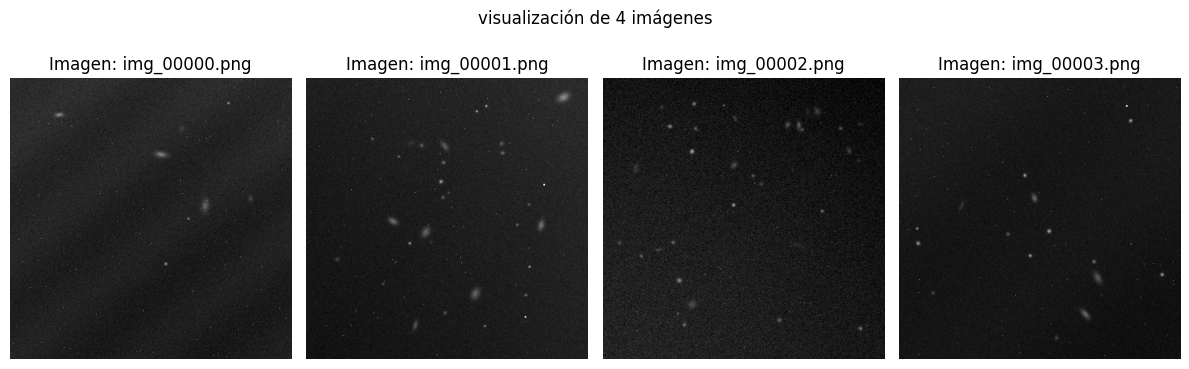

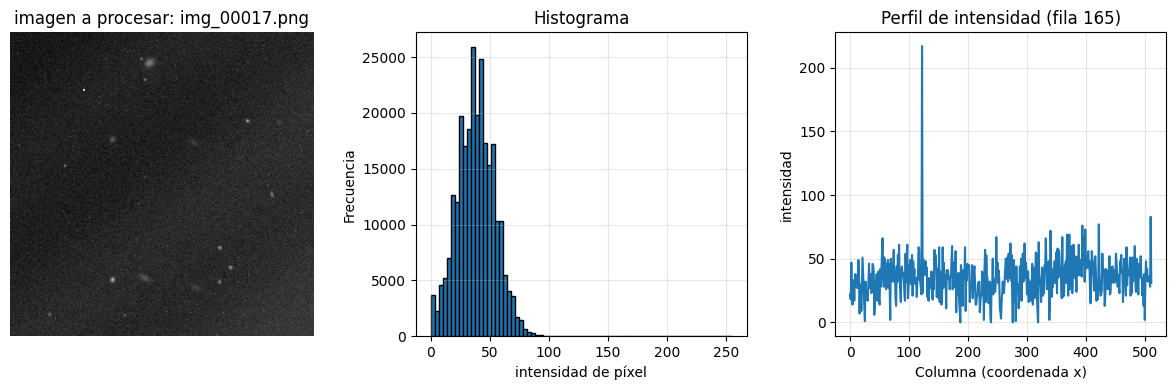

In [99]:
# TODO: visualizar ejemplos de imágenes
# TODO: graficar histograma de intensidades
# TODO: graficar perfil de intensidad de una fila o columna

fig, axes = plt.subplots(1, 4, figsize=(12, 4)) #4 imagenes en pantalla
axes = axes.ravel()

imagenes_seleccionadas =   listado_img[:4] #4 primeras imagenes del listado

for i, ruta in enumerate(imagenes_seleccionadas): #visualizacion en escala de grises
    img =   io.imread(ruta, as_gray=True)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Imagen: {ruta.name}")
    axes[i].axis('off')

plt.suptitle("visualización de 4 imágenes")
plt.tight_layout()
plt.show()

imagen_ejemplo = 17 #permite seleccionar cualquier imagen del listado de la 0 a la 59

ext_img = listado_img[imagen_ejemplo] #extraccion de la imagen y  sus datos correspondientes
nombre_ext_img = ext_img.name
img_original = io.imread(ext_img, as_gray=True)

fig2, axes2= plt.subplots(1, 3, figsize=(12, 4))

axes2[0].imshow(img_original, cmap='gray') #imagen seleccionada para procesar
axes2[0].set_title(f"imagen a procesar: {nombre_ext_img}")
axes2[0].axis('off')

axes2[1].hist(img_original.ravel(), bins=75, edgecolor='black') #histograma pasado de 2D a 1D con ravel
axes2[1].set_title("Histograma")
axes2[1].set_xlabel("intensidad de píxel")
axes2[1].set_ylabel("Frecuencia")
axes2[1].grid(True, alpha=0.3)

columna_seleccionada =165 #se extrae la coordenada de una columna aleatoria de la imagen 
perfil_intensidad = img_original[:, columna_seleccionada] #extraer valores de la columna para plotearlos

axes2[2].plot(perfil_intensidad)
axes2[2].set_title(f"Perfil de intensidad (fila {columna_seleccionada})")
axes2[2].set_xlabel("Columna (coordenada x)")
axes2[2].set_ylabel("intensidad")
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Filtrado y denoising

**Tarea:** implementa y compara al menos tres métodos de filtrado. Ejemplos: filtro promedio, filtro gaussiano, filtro de mediana, filtro bilateral o denoising con wavelets.

Discute cuál método preserva mejor los objetos débiles y cuál elimina mejor los píxeles calientes.

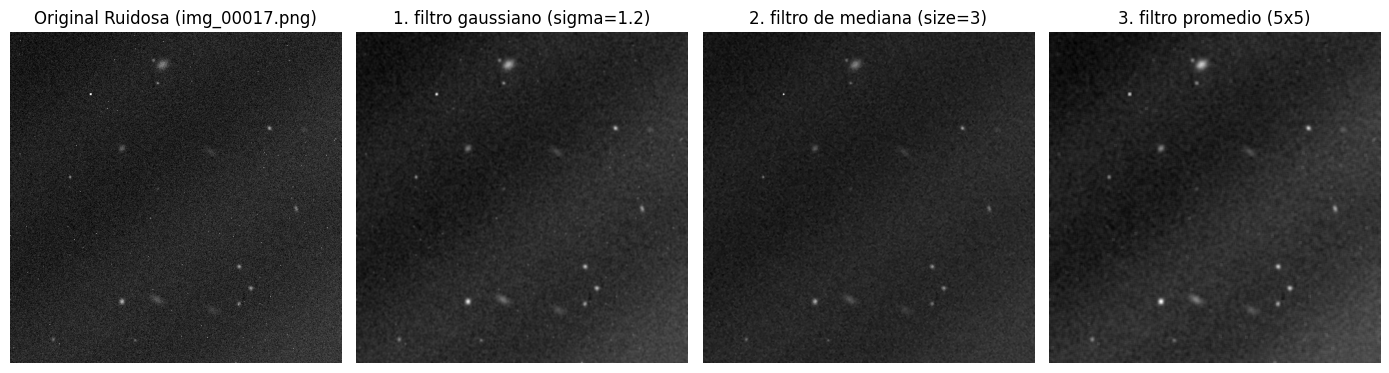

In [ ]:
# TODO: implementar al menos tres filtros
# TODO: mostrar imagen original vs imágenes filtradas
# TODO: comentar visualmente las diferencias

gaussiano =  gaussian(img_original, sigma=1.2)  # filtro gaussiano

mediana =  median_filter(img_original, size=3)  # filtro de mediana

promedio = uniform_filter(img_original, size=5)  # filtro promedio

fig, axes =plt.subplots(1, 4, figsize=(14, 10))  # comparacion de los filtros con la imagen original
ax = axes.ravel()

ax[0].imshow(img_original, cmap='gray')
ax[0].set_title(f"Original Ruidosa ({nombre_ext_img})")

ax[1].imshow(gaussiano, cmap='gray')
ax[1].set_title("1. filtro gaussiano (sigma=1.2)")

ax[2].imshow(mediana, cmap='gray')
ax[2].set_title("2. filtro de mediana (size=3)")

ax[3].imshow(promedio, cmap='gray')
ax[3].set_title("3. filtro promedio (5x5)")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

img_filtrada = mediana.copy()  # se asigna nueva variable a la imagen seleccionada para seguir procesando

#el más efectivo es el filtro de mediana, ya que elimina los píxeles calientes pero a su vez mantiene los objetos restantes en la imagen,
#a diferencia de los otros dos filtros que preservan obejtos débiles pero también pixeles calientes.

## 4. Estimación y corrección de fondo

El fondo astronómico no es constante. Debes estimar una imagen de fondo suave $\hat{B}(x,y)$ y restarla:

$$I_{\mathrm{corr}}(x,y)=I_{\mathrm{obs}}(x,y)-\hat{B}(x,y)$$

**Tarea:** prueba al menos un método de corrección de fondo.

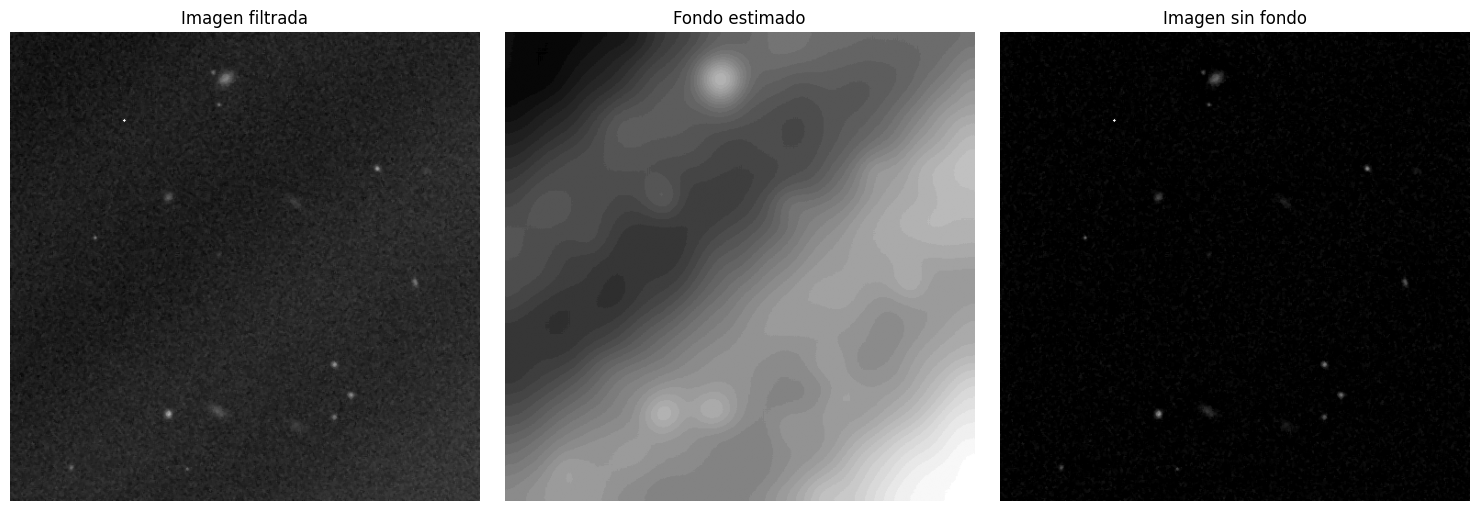

In [101]:
# TODO: estimar fondo usando filtro gaussiano ancho, mediana ancho, apertura morfológica o ajuste suave
# TODO: restar el fondo
# TODO: mostrar imagen original, fondo estimado e imagen corregida

fondo_estimado =   cv2.GaussianBlur(img_filtrada, (101, 101), 0) #filtro gaussiano con un kernel alto para que el filtro sea ancho

imagen_operada = img_filtrada.astype(np.int16) - fondo_estimado.astype(np.int16) #se evita underflow al pasar a int16 (que valores bajo 0 generan errores)

imagen_corregida =  np.clip(imagen_operada, 0, 255).astype(np.uint8) #los valores negativos se pasan a 0 y se deuelve la imagen a 0-255 uint8 

fig_fondo, ejes_b= plt.subplots(1, 3, figsize=(15, 5))
ejes_b[0].imshow(img_filtrada, cmap='gray'); ejes_b[0].set_title('Imagen filtrada')
ejes_b[1].imshow(fondo_estimado, cmap='gray'); ejes_b[1].set_title('Fondo estimado')
ejes_b[2].imshow(imagen_corregida, cmap='gray'); ejes_b[2].set_title('Imagen sin fondo')
for ax in ejes_b: ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Realce de contraste

**Tarea:** aplica normalización, transformación gamma, ecualización de histograma o ecualización adaptativa. Explica cómo cambia la visibilidad de los objetos débiles.

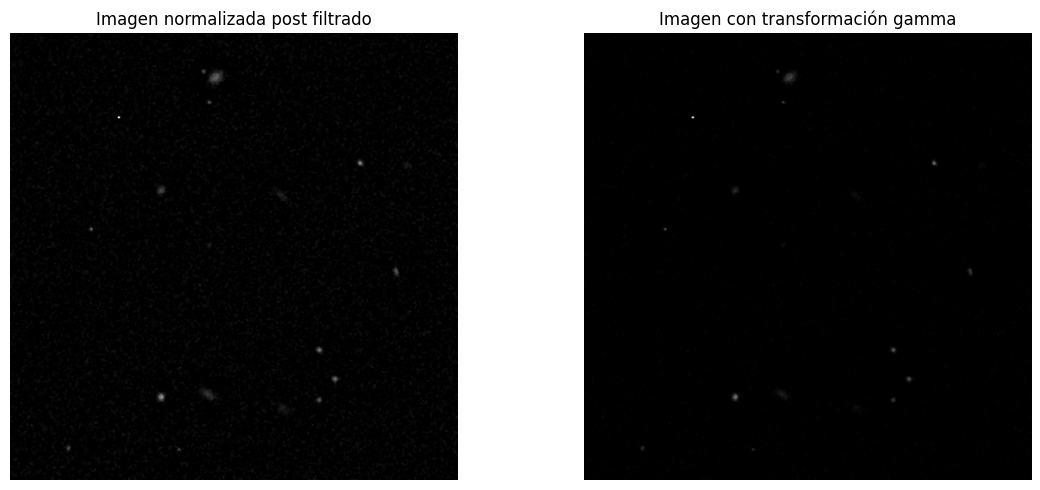

In [ ]:
# TODO: aplicar realce de contraste
# TODO: comparar antes/despues

v_min =  np.min(imagen_corregida) #normalizar datos (rango de 0 a 1) de la imagen obtenida del paso anterior
v_max = np.max(imagen_corregida)

if v_max > v_min:   #en caso de ser cero (ambas imagenes iguales) devuelve la misma imagen 
    img_normalizada = (imagen_corregida - v_min) / (v_max - v_min)
else:
    img_normalizada = imagen_corregida

potencia_gamma = 1.4 #potencia a elevar
img_contraste =  np.power(img_normalizada, potencia_gamma) #transformacion gamma siguiendo la formula elevando los valores de los pixeles a una potencia

fig, axes= plt.subplots(1, 2, figsize=(12, 5)) #resultados
axes[0].imshow(img_normalizada, cmap='gray')
axes[0].set_title("Imagen normalizada post filtrado")
axes[0].axis('off')

axes[1].imshow(img_contraste, cmap='gray')
axes[1].set_title(f"Imagen con transformación gamma")
axes[1].axis('off')

plt.tight_layout()
plt.show()

#En este caso la visibilidad de los objetos débiles disminuye aun más, lo que facilita el tratamiento posterior de segmentación.

## 6. Segmentación

Debes construir una máscara binaria:

$$M(x,y)=1 \quad \text{si hay objeto detectado}$$

**Tarea:** implementa un método de umbralización. Puedes usar umbral global, Otsu, adaptativo, o un umbral de la forma:

$$T = \mu_B + k\sigma_B$$

Media del fondo: 0.0029
Desviación estándar (ruido): 0.0097
Umbral calculado (T): 0.0369


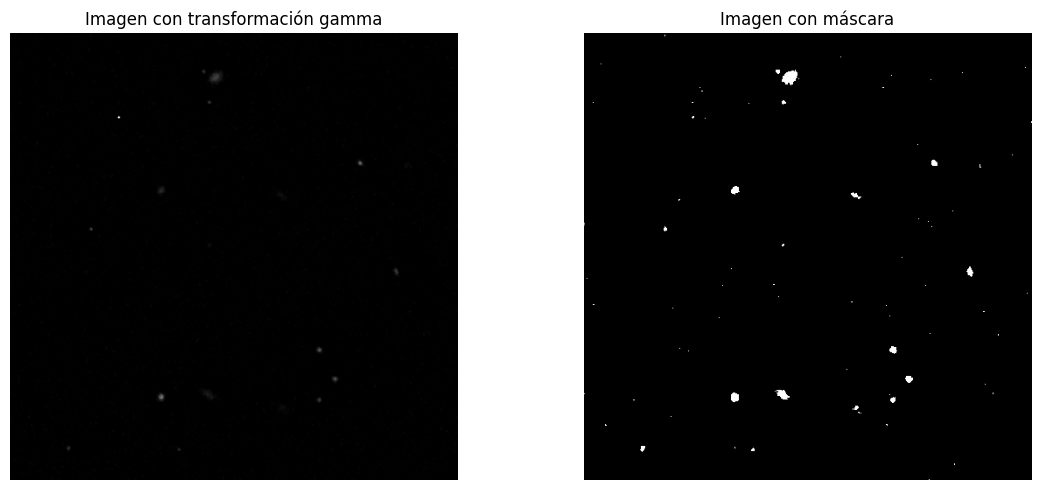

In [111]:
# TODO: calcular umbral
# TODO: generar máscara binaria
# TODO: mostrar imagen corregida y máscara

media_umbral = np.mean(img_contraste) #se seleccionó el umbral estadístico T segun la formula dada
desviacion_umbral  = np.std(img_contraste)

k = 3.5 #tolerancia al ruido (un k alto puede eliminar estrellas verdaderas, un k bajo puede detectar más falsos positivos)
umbral =   media_umbral + (k * desviacion_umbral)

print(f"Media del fondo: {media_umbral:.4f}")
print(f"Desviación estándar (ruido): {desviacion_umbral:.4f}")
print(f"Umbral calculado (T): {umbral:.4f}")

mascara_binaria= (img_contraste > umbral).astype(np.uint8) #mascara binaria con la condicion que todo lo mayor al umbral es 1 y lo menor al umbral es 0

fig, axes =plt.subplots(1, 2, figsize=(12, 5)) #resultados
axes[0].imshow(img_contraste, cmap='gray')
axes[0].set_title("Imagen con transformación gamma")
axes[0].axis('off')

axes[1].imshow(mascara_binaria, cmap='gray')
axes[1].set_title(f"Imagen con máscara")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 7. Morfología matematica

**Tarea:** limpia la máscara usando erosión, dilatación, apertura, cierre, relleno de huecos o eliminación de objetos pequeños.

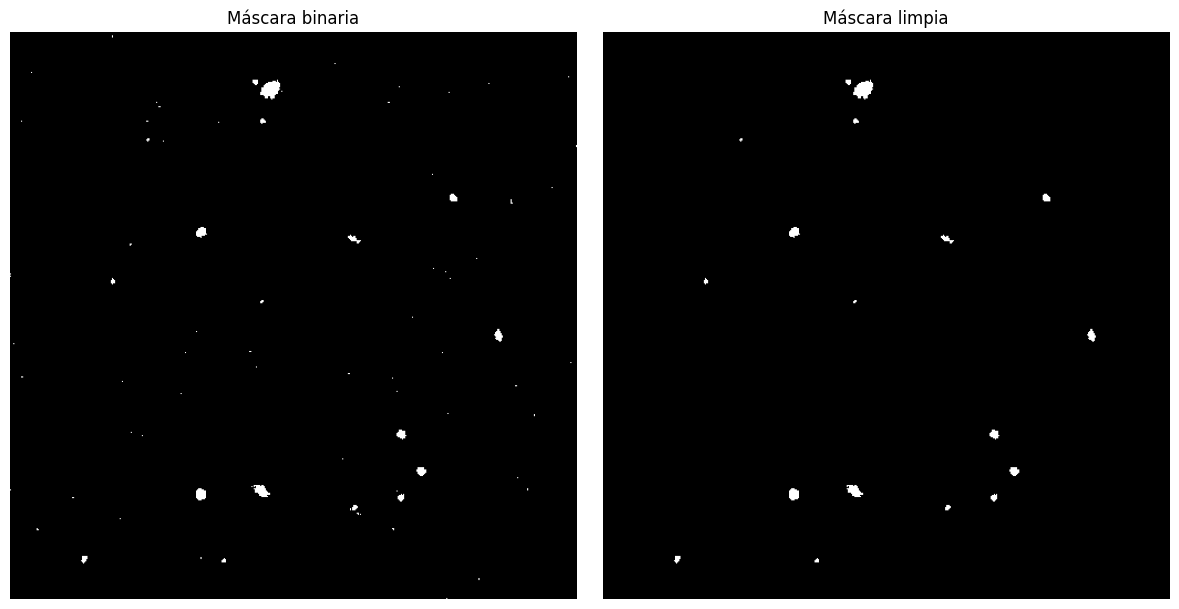

In [112]:
# TODO: aplicar operaciones morfológicas
# TODO: comparar máscara antes y despues

mascara_eliminacion   = mascara_binaria.astype(bool) # los boolean facilitan el uso de morfologia en skimage

mascara_eliminacion =  remove_small_objects(mascara_eliminacion, max_size=5) #elimina objetos menores a 5 pixeles 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mascara_binaria, cmap='gray')
axes[0].set_title("Máscara binaria")
axes[0].axis('off')

axes[1].imshow(mascara_eliminacion, cmap='gray')
axes[1].set_title("Máscara limpia")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 8. Componentes conectados y medición de objetos

**Tarea:** etiqueta los componentes conectados de la máscara final. Para cada objeto detectado estima:

- centroide $(\hat{x},\hat{y})$,
- area,
- brillo total,
- brillo medio.

El resultado puede quedar como un `DataFrame` interno llamado `pred_catalog`.

Objetos detectados en la imagen: 18


,filename,object_id_pred,x_pred,y_pred,area,mean_brightness,total_brightness,peak_pred,sigma_x_pred,sigma_y_pred,object_type_pred
0,img_00017.png,1,221.142857,44.666667,21.0,40.333333,847.0,64.0,2.411447,2.784616,star
1,img_00017.png,2,234.917874,51.454106,207.0,44.816425,9277.0,85.0,7.001444,9.708925,galaxy_like
2,img_00017.png,3,227.764706,79.941176,17.0,44.470588,756.0,81.0,2.194572,2.545186,star
3,img_00017.png,4,124.166667,96.833333,6.0,185.500000,1113.0,221.0,1.154701,1.563472,star
4,img_00017.png,5,399.804878,149.341463,41.0,57.487805,2357.0,116.0,3.201511,4.103530,star


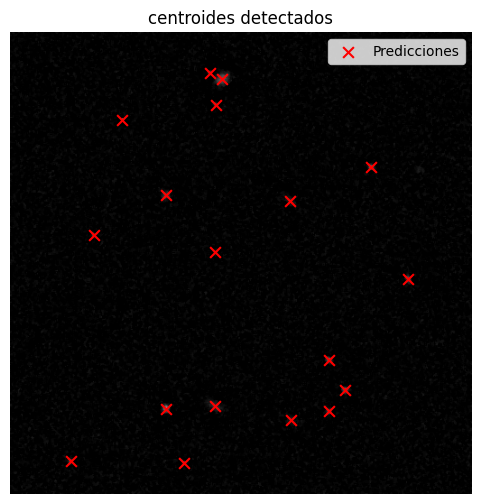

In [113]:
# TODO: etiquetar componentes conectados
# TODO: medir centroide, area y brillo de cada objeto
# TODO: construir pred_catalog con columnas: filename, object_id_pred, x_pred, y_pred, area, total_brightness, mean_brightness

datos_objetos = []
enumerar_img =label(mascara_eliminacion)  # cada objeto identificado recibe un número único (1, 2, ...)

num_objetos = enumerar_img.max()
print(f"Objetos detectados en la imagen: {num_objetos}")

propiedades =  regionprops(enumerar_img, intensity_image=imagen_corregida)

for i, prop in enumerate(propiedades):

    y1, x1 = prop.centroid

    # sigma_x y sigma_y describen el ancho del objeto en los ejes,las estrellas tienen sigma pequeño y simetrico y las galaxias son mas anchas y asimetricas
    sigma_x = prop.axis_minor_length / 2  # semieje menor: ancho en la direccion más compacta
    sigma_y= prop.axis_major_length / 2  #semieje mayor: ancho en la direccion mas extendida

    peak_val = prop.intensity_max  # las estrellas tienen peak alto y concentrado

   # clasificación por sigma_y, es el mejor discriminador, estrellas compactas vs galaxias extendidas
    #umbral en 4.6 px que es el punto medio entre la mediana de estrellas (3.11) y galaxias (6.14) del dataset, peak se usa como 
    # criterio secundario para casos intermedios entre 3.5 < sigma_y < 5.5
    if sigma_y < 3.5:
        tipo_pred = 'star'   # objeto muy compacto, estrella
    elif sigma_y > 5.5:
        tipo_pred = 'galaxy_like'   # objeto muy extendido, galaxia
    else:
        tipo_pred ='star' if peak_val >= 70 else 'galaxy_like'  # zona intermedia, desempate segun peak

    datos_objetos.append({
        'filename': nombre_ext_img,
        'object_id_pred':i + 1,
        'x_pred': x1,
        'y_pred': y1,
        'area':prop.area,
        'mean_brightness': prop.intensity_mean,
        'total_brightness':prop.intensity_mean * prop.area,
        'peak_pred':peak_val,
        'sigma_x_pred': sigma_x,
        'sigma_y_pred': sigma_y,
        'object_type_pred':tipo_pred  # clasificación preliminar para comparar con el catálogo real
    })

pred_catalog =   pd.DataFrame(datos_objetos)

display(pred_catalog.head())

plt.figure(figsize=(6, 6))
plt.imshow(imagen_corregida, cmap='gray')
plt.title("centroides detectados")
plt.scatter(pred_catalog['x_pred'], pred_catalog['y_pred'], c='red', marker='x', s=60, label='Predicciones')
plt.legend()
plt.axis('off')
plt.show()

## 9. Emparejamiento con el catálogo verdadero

Para calcular el error de centroide, cada detección debe emparejarse con un objeto verdadero cercano. Define una tolerancia $r_{tol}$ en píxeles.

Una detección puede considerarse correcta si:

$$\sqrt{(x_i-\hat{x}_j)^2+(y_i-\hat{y}_j)^2} < r_{tol}$$

In [114]:
# TODO: implementar emparejamiento entre pred_catalog y true_catalog
# Sugerencia: para cada imagen, usar distancia euclidiana entre centroides verdaderos y predichos
# TODO: definir r_tol y justificarlo

catalogo_real= true_catalog[true_catalog['filename'] == nombre_ext_img]

r_tol = 5.0  # tolerancia en pixeles
detecciones_correctas = 0
errores_centroide = []

tabla_emparejados = [] #acumula cada par (real, predicho) que quedó dentro de la tolerancia
vistos_emparejados =set()

for index, pred in pred_catalog.iterrows():

    distancias = np.sqrt((catalogo_real['x'] - pred['x_pred'])**2 + (catalogo_real['y'] - pred['y_pred'])**2)

    distancia_minima  = distancias.min()
    idx_mas_cercano  = distancias.idxmin()

    if distancia_minima < r_tol:
        vistos_emparejados.add(idx_mas_cercano)
        detecciones_correctas += 1
        errores_centroide.append(distancia_minima)

        fila_real = catalogo_real.loc[idx_mas_cercano]
        tabla_emparejados.append({
            #datos del catálogo verdadero
            'x_real' : fila_real['x'],
            'y_real':  fila_real['y'],
            'object_type': fila_real['object_type'],   # tipo real: 'star' o 'galaxy_like'
            'peak_real': fila_real['peak_intensity'],
            'sigma_x_real':fila_real['sigma_x'],        # ancho real del objeto en x
            'sigma_y_real': fila_real['sigma_y'],        # ancho real del objeto en y
            #datos de la predicción
            'x_pred':pred['x_pred'],
            'y_pred': pred['y_pred'],
            'object_type_pred':pred['object_type_pred'],   # clasificación predicha para comparar
            'peak_pred': pred['peak_pred'],
            'sigma_x_pred':pred['sigma_x_pred'],
            'sigma_y_pred':pred['sigma_y_pred'],
            'error_centroide': distancia_minima
        })

df_emparejados = pd.DataFrame(tabla_emparejados)

error_medio =  np.mean(errores_centroide)
total_detectados = len(pred_catalog)
total_reales= len(catalogo_real)

print(f"Total de objetos reales ({nombre_ext_img}): {total_reales}")
print(f"Total de objetos detectados: {total_detectados}")
print(f"Detecciones correctas: {detecciones_correctas}")
print(f"Error medio de centroide: {error_medio:.4f} píxeles")
print(f"\nTabla de aciertos emparejados (real vs predicho):")
display(df_emparejados.head())


Total de objetos reales (img_00017.png): 18
Total de objetos detectados: 18
Detecciones correctas: 17
Error medio de centroide: 0.4466 píxeles

Tabla de aciertos emparejados (real vs predicho):


,x_real,y_real,object_type,peak_real,sigma_x_real,sigma_y_real,x_pred,y_pred,object_type_pred,peak_pred,sigma_x_pred,sigma_y_pred,error_centroide
0,220.909,44.539,star,91.718,1.670,1.723,221.142857,44.666667,star,64.0,2.411447,2.784616,0.266436
1,234.851,51.326,galaxy_like,97.466,5.792,4.645,234.917874,51.454106,galaxy_like,85.0,7.001444,9.708925,0.144511
2,227.319,79.789,star,127.300,1.302,1.145,227.764706,79.941176,star,81.0,2.194572,2.545186,0.470969
3,399.778,149.498,star,151.313,1.739,1.952,399.804878,149.341463,star,116.0,3.201511,4.103530,0.158827
4,172.425,180.430,galaxy_like,68.682,3.620,2.933,172.242424,180.287879,galaxy_like,62.0,4.135169,5.207848,0.231371


## 10. Métricas obligatorias

Debes reportar claramente:

### Error de conteo

$$E_N = |N_{pred} - N_{true}|$$

Reporta media, mediana y/o histograma de $E_N$ sobre el conjunto de imágenes.

### Error de centroide

$$e_c^{(i)} = \sqrt{(x_i-\hat{x}_i)^2+(y_i-\hat{y}_i)^2}$$

Reporta media, mediana y desviacion estandar del error de centroide en píxeles.

Métricas error de conteo — imagen img_00017.png
Objetos reales: 18
Objetos predichos: 18
Error de conteo: 0
Media: 0.0000  |  Mediana: 0.0000

Resultado de las detecciones
Aciertos: 17
Falsos positivos : 1
Falsos negativos: 1

Métricas del error de centroide (píxeles)
Media : 0.4466
Mediana: 0.2664
Desviacion estandar : 0.3786

Comparación — catálogo real vs resultados del procesamiento
                         Real  Encontrado  Aciertos
 Estrellas                 11          11     10
 Galaxias                   7           6      5

  Clasificación total correcta: 15 de 18  (83.3%)


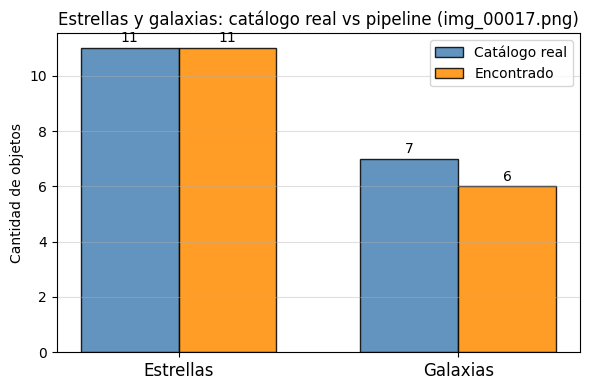

In [115]:
# TODO: calcular E_N por imagen
# TODO: calcular error de centroide para objetos emparejados
# TODO: mostrar métricas finales

N_pred = len(pred_catalog)  #se calcula el error de conteo, media, mediana e histograma
N_true =  len(catalogo_real)
E_N = abs(N_pred - N_true)

errores_conteo = [E_N]
media_en= np.mean(errores_conteo)
mediana_en = np.median(errores_conteo)

verdaderos_positivos  = detecciones_correctas
falsos_positivos_n = N_pred - verdaderos_positivos
falsos_negativos_n = N_true - verdaderos_positivos

media_ec= np.mean(errores_centroide)
mediana_ec = np.median(errores_centroide)
std_ec = np.std(errores_centroide)

print(f"Métricas error de conteo — imagen {nombre_ext_img}")
print(f"Objetos reales: {N_true}")
print(f"Objetos predichos: {N_pred}")
print(f"Error de conteo: {E_N}")
print(f"Media: {media_en:.4f}  |  Mediana: {mediana_en:.4f}")

print("\nResultado de las detecciones")
print(f"Aciertos: {verdaderos_positivos}")
print(f"Falsos positivos : {falsos_positivos_n}")
print(f"Falsos negativos: {falsos_negativos_n}")

print("\nMétricas del error de centroide (píxeles)")
print(f"Media : {media_ec:.4f}")
print(f"Mediana: {mediana_ec:.4f}")
print(f"Desviacion estandar : {std_ec:.4f}")

#comparativa real vs predicho en estrellas y/o galaxias
if len(df_emparejados) == 0:
    print("\nno hay aciertos para analizar.")
else:
    # conteo en el catálogo real
    n_stars_real_img= (catalogo_real['object_type'] == 'star').sum()
    n_gals_real_img = (catalogo_real['object_type'] == 'galaxy_like').sum()

    #conteo de los aciertos solamente
    n_stars_pred_img = (df_emparejados['object_type_pred'] == 'star').sum()
    n_gals_pred_img= (df_emparejados['object_type_pred'] == 'galaxy_like').sum()

    #separación de objetos encontrados en los aciertos
    stars_emp = df_emparejados[df_emparejados['object_type'] == 'star']
    gals_emp = df_emparejados[df_emparejados['object_type'] == 'galaxy_like']

    ok_stars = (stars_emp['object_type_pred'] == 'star').sum()
    ok_gals = (gals_emp['object_type_pred']  == 'galaxy_like').sum()

    pct_stars = 100 * ok_stars / len(stars_emp) if len(stars_emp) > 0 else 0
    pct_gals = 100 * ok_gals  / len(gals_emp)  if len(gals_emp)  > 0 else 0
    pct_total =  100 * (ok_stars + ok_gals) / N_true

    print(f"\nComparación — catálogo real vs resultados del procesamiento")
    print(f" {'':20s}  {'Real':>6}  {'Encontrado':>10}  {'Aciertos':>5}")
    print(f" {'Estrellas':20s}  {n_stars_real_img:>6}  {n_stars_pred_img:>10}  {ok_stars:>5}")
    print(f" {'Galaxias':20s}  {n_gals_real_img:>6}  {n_gals_pred_img:>10}  {ok_gals:>5}")
    print(f"\n  Clasificación total correcta: {ok_stars + ok_gals} de {N_true}  ({pct_total:.1f}%)")

    #histograma comparativo: real vs encontrado
    categorias = ['Estrellas', 'Galaxias']
    valores_real = [n_stars_real_img, n_gals_real_img]
    valores_pred =  [n_stars_pred_img, n_gals_pred_img]

    x = np.arange(len(categorias))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))
    barras_real =  ax.bar(x - ancho/2, valores_real, ancho, label='Catálogo real', color='steelblue',  edgecolor='black', alpha=0.85)
    barras_pred = ax.bar(x + ancho/2, valores_pred, ancho, label='Encontrado',    color='darkorange', edgecolor='black', alpha=0.85)

    for barra in list(barras_real) + list(barras_pred):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1,
                str(int(barra.get_height())), ha='center', va='bottom', fontsize=10)

    ax.set_xticks(x); ax.set_xticklabels(categorias, fontsize=12)
    ax.set_ylabel("Cantidad de objetos")
    ax.set_title(f"Estrellas y galaxias: catálogo real vs pipeline ({nombre_ext_img})")
    ax.legend(); ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()        

## 11. Ejemplos visuales correctos e incorrectos

Incluye hasta 10 ejemplos representativos:

- detecciones correctas,
- falsos positivos,
- falsos negativos,
- casos difíciles por fondo, ruido o objetos débiles.

No necesitas entregar una carpeta con imágenes procesadas. Las figuras deben quedar visibles en este notebook y resumidas en el reporte.

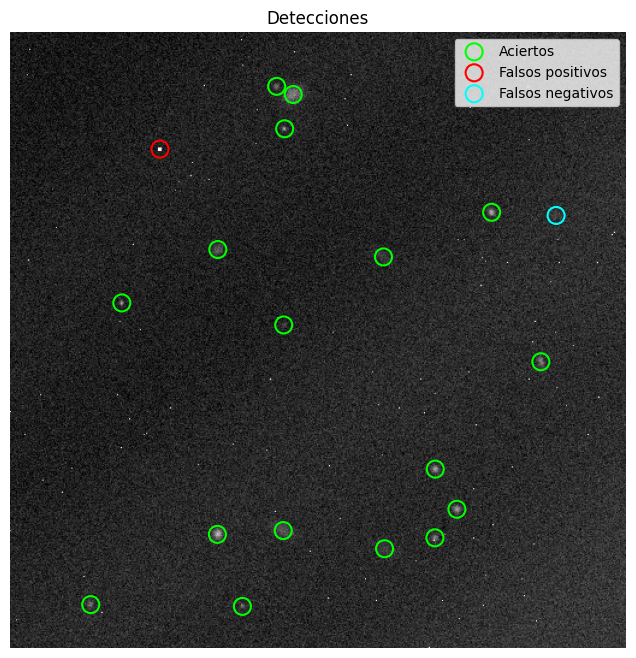

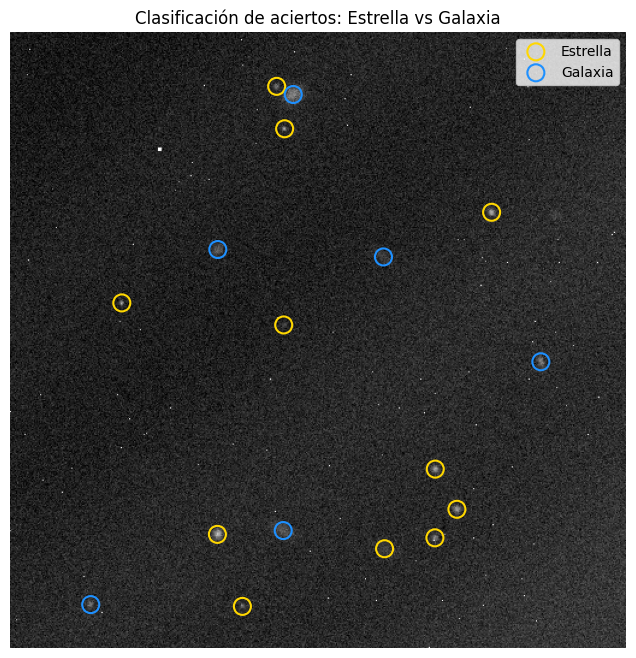

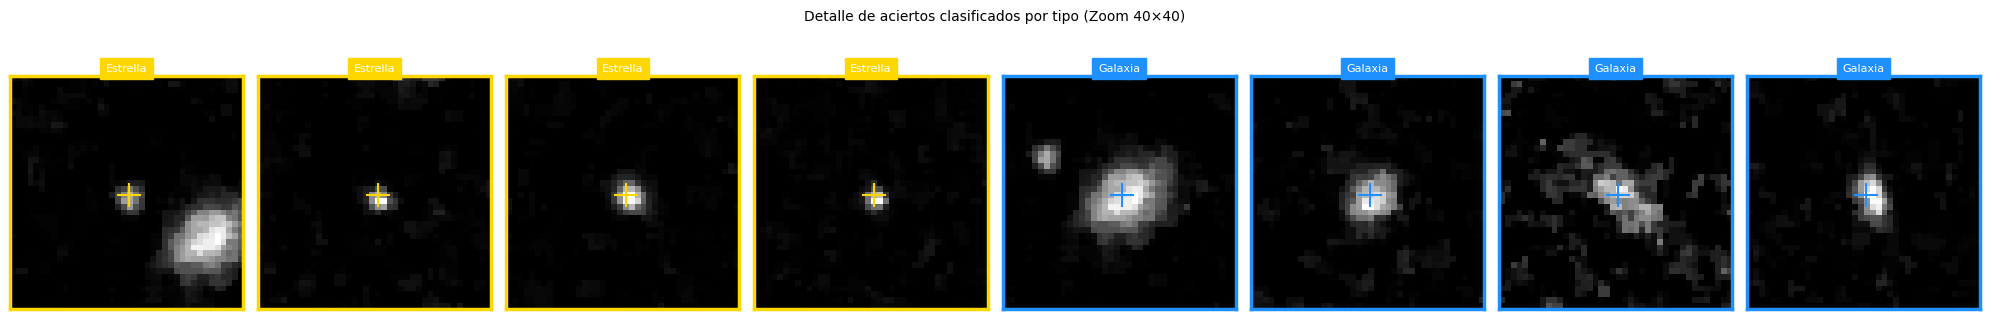

In [116]:
# TODO: graficar ejemplos representativos con el catálogo verdadero y tus detecciones superpuestas
# Puedes usar marcadores de distinto color para verdad y prediccion

aciertos, falsos_positivos = [], []
vistos = set()
aciertos_con_tipo = []  # guarda también el tipo predicho para la figura extra

for idx, pred in pred_catalog.iterrows():
    dist =  np.hypot(catalogo_real['x'] - pred['x_pred'], catalogo_real['y'] - pred['y_pred'])  # np.hypot calcula la distancia euclidiana de forma directa

    if dist.min() < r_tol:
        aciertos.append((pred['x_pred'], pred['y_pred']))  # si la distancia minima está bajo la tolerancia, es un acierto
        vistos.add(dist.idxmin())
        aciertos_con_tipo.append((pred['x_pred'], pred['y_pred'], pred['object_type_pred']))  # guardar el tipo predicho para la figura extra
    else:
        falsos_positivos.append((pred['x_pred'], pred['y_pred']))  # sino es un falso positivo

falsos_negativos = [(r['x'], r['y']) for i, r in catalogo_real.iterrows() if i not in vistos]  # los que no se guardaron en vistos son falsos negativos

#encuentros totales
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_original, cmap='gray')

grupos = [
    (aciertos,'lime', 'Aciertos'),
    (falsos_positivos, 'red','Falsos positivos'),
    (falsos_negativos, 'cyan', 'Falsos negativos'),
]

for puntos, color, label_texto in grupos:  # se asignan los grupos
    if puntos:
        x, y = np.array(puntos).T  # divide los pares en dos arreglos para usar scatter
        ax.scatter(x, y, edgecolor=color, facecolors='none', s=150, lw=1.5, label=label_texto)

ax.legend(); ax.axis('off')
plt.title("Detecciones")
plt.show()

#galaxias y estrellas solo en aciertos
fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.imshow(img_original, cmap='gray')

stars_coords = [(x, y) for x, y, t in aciertos_con_tipo if t == 'star']
galaxy_coords =  [(x, y) for x, y, t in aciertos_con_tipo if t == 'galaxy_like']

for coords, color, label_texto in [(stars_coords,  'gold', 'Estrella'),
                                    (galaxy_coords, 'dodgerblue', 'Galaxia')]:
    if coords:
        xc, yc = np.array(coords).T
        ax2.scatter(xc, yc, edgecolor=color, facecolors='none', s=150, lw=1.5, label=label_texto)

ax2.legend(); ax2.axis('off')
plt.title("Clasificación de aciertos: Estrella vs Galaxia")
plt.show()

#ejemplos encontrados con zoom 
ejemplos_tipo = (
    [(x, y, 'Estrella', 'gold') for x, y, t in aciertos_con_tipo if t == 'star'][:4]       +
    [(x, y, 'Galaxia', 'dodgerblue') for x, y, t in aciertos_con_tipo if t == 'galaxy_like'][:4]
)

if ejemplos_tipo:
    n = len(ejemplos_tipo)  # número real de parches, no siempre 8
    fig3, axes3 = plt.subplots(1, n, figsize=(2.5 * n, 3.5))
    if n == 1:
        axes3 = [axes3]  # si solo hay un parche, subplots no devuelve lista
    for ax3, (cx, cy, label_texto, color) in zip(axes3, ejemplos_tipo):
        x, y = int(cx), int(cy)
        recorte =  img_contraste[max(0, y-20):y+20, max(0, x-20):x+20]
        ax3.imshow(recorte, cmap='gray')
        ax3.scatter(recorte.shape[1]//2, recorte.shape[0]//2, c=color, marker='+', s=300)
        ax3.set_title(label_texto, fontsize=8, color='white', backgroundcolor=color, pad=3)
        for spine in ax3.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
        ax3.set_xticks([]); ax3.set_yticks([])
    plt.suptitle("Detalle de aciertos clasificados por tipo (Zoom 40×40)", fontsize=10)
    plt.tight_layout()
    plt.show()

## Extra: Iteración para las 60 imágenes

Procesamiento de 60 imágenes en 8.64 s

Metricas finales
Objetos reales totales: 1240
Aciertos : 1159
Falsos positivos: 25
Falsos negativos : 81

Error de conteo promedio: 1.33 objetos/imagen
Error de centroide medio: 0.375 px
Error de centroide mediano : 0.274 px
Desviación estándar centroide: 0.425 px

Comparación — catálogo real vs resultados del procesamiento (60 imágenes)
                          Real  Encontrado        Aciertos
  Estrellas                880         761        725
  Galaxias                 360         398        293

  Clasificación total correcta: 1018 de 1240  (82.1%)


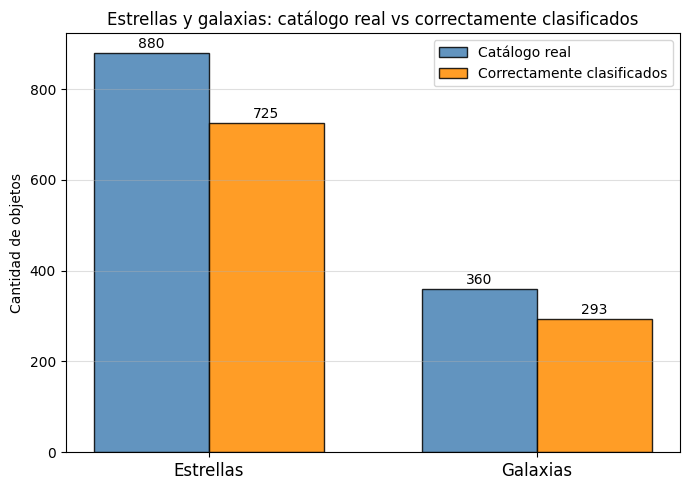

In [119]:
import time
from skimage.measure import label, regionprops
inicio = time.time()

errores_conteo_global = []
errores_centroide_global = []
total_aciertos =  0
total_falsos_positivos = 0
total_falsos_negativos = 0
resultados_por_imagen= []                       

# listas para el análisis de peak y sigma por tipo de objeto
peaks_reales_stars = []; peaks_pred_stars = []
peaks_reales_gals= []; peaks_pred_gals = []
sigmax_reales_stars =  []; sigmax_pred_stars = []
sigmax_reales_gals = []; sigmax_pred_gals = []
sigmay_reales_stars = []; sigmay_pred_stars = []
sigmay_reales_gals = []; sigmay_pred_gals = []
tipos_pred_global = []; tipos_real_global  = []

for ruta_img in listado_img:
    nombre  = ruta_img.name
    img_raw =  io.imread(ruta_img, as_gray=True)

    #PASO 1:filtro de mediana para eliminar pixeles calientes
    img_filtrada_loop = median_filter(img_raw, size=3)

    #PASO 2:corrección de fondo con GaussianBlur de kernel ancho
    fondo_loop = cv2.GaussianBlur(img_filtrada_loop, (101, 101), 0)
    imagen_operada_loop = img_filtrada_loop.astype(np.int16) - fondo_loop.astype(np.int16)  # evita underflow
    img_corregida_loop = np.clip(imagen_operada_loop, 0, 255).astype(np.uint8)

    # PASO 3:normalización y transformación gamma para realzar objetos débiles
    v_min, v_max = img_corregida_loop.min(), img_corregida_loop.max()
    img_norm_loop = (img_corregida_loop - v_min) / (v_max - v_min) if v_max > v_min else img_corregida_loop
    img_contraste_loop = np.power(img_norm_loop, 1.4)

    #PASO 4: umbral estadistico T = media + k*sigma
    umbral_loop = img_contraste_loop.mean() + 3.5 * img_contraste_loop.std()
    mascara_loop = img_contraste_loop > umbral_loop

    # PASO 5:eliminar regiones pequeñas (< 5 px) que son ruido residual
    mascara_limpia_loop = remove_small_objects(mascara_loop, max_size=5)

    #PASO 6: etiquetar componentes y extraer propiedades morfologicas
    etiquetas_loop = label(mascara_limpia_loop)
    props_loop = regionprops(etiquetas_loop, intensity_image=img_corregida_loop)

    coords_pred_loop = []
    peaks_loop = []
    sigmax_loop = []
    sigmay_loop = []
    tipos_loop = []

    for p in props_loop:
        cy, cx = p.centroid
        peak_v = p.intensity_max
        sx = p.axis_minor_length / 2
        sy = p.axis_major_length / 2

        # clasificación calibrada con medianas del catalogo: sigma_y es el discriminador principal
        if sy < 3.5:
            tipo_pred = 'star'
        elif sy > 5.5:
            tipo_pred = 'galaxy_like'
        else:
            tipo_pred = 'star' if peak_v >= 70 else 'galaxy_like'  # zona intermedia - desempate por peak

        coords_pred_loop.append([cy, cx])
        peaks_loop.append(peak_v)
        sigmax_loop.append(sx)
        sigmay_loop.append(sy)
        tipos_loop.append(tipo_pred)

    coords_pred_loop = np.array(coords_pred_loop) if coords_pred_loop else np.empty((0, 2))
    N_pred_img = len(coords_pred_loop)

    #PASO 7: cargar objetos reales de esta imagen
    reales_loop = true_catalog[true_catalog['filename'] == nombre]
    N_real_img = len(reales_loop)

    aciertos_img = 0
    errores_cent_img = []

    #PASO 8: emparejamiento por distancia euclidiana mínima con tolerancia de 4 px
    if N_pred_img > 0 and N_real_img > 0:
        coords_reales = reales_loop[['y', 'x']].values
        mat_dist = cdist(coords_pred_loop, coords_reales)

        usados = set()
        for i_pred in range(N_pred_img):
            idx_cercano = np.argmin(mat_dist[i_pred])
            dist_min = mat_dist[i_pred, idx_cercano]

            if dist_min < 5.0 and idx_cercano not in usados:
                usados.add(idx_cercano)
                errores_centroide_global.append(dist_min)
                errores_cent_img.append(dist_min)
                aciertos_img += 1

                #se guarda peak, sigma y tipo solo para los aciertos
                fila_real = reales_loop.iloc[idx_cercano]
                tipo_real =  fila_real['object_type']
                tipos_pred_global.append(tipos_loop[i_pred])
                tipos_real_global.append(tipo_real)

                if tipo_real == 'star':
                    peaks_reales_stars.append(fila_real['peak_intensity'])
                    peaks_pred_stars.append(peaks_loop[i_pred])
                    sigmax_reales_stars.append(fila_real['sigma_x'])
                    sigmax_pred_stars.append(sigmax_loop[i_pred])
                    sigmay_reales_stars.append(fila_real['sigma_y'])
                    sigmay_pred_stars.append(sigmay_loop[i_pred])
                else:
                    peaks_reales_gals.append(fila_real['peak_intensity'])
                    peaks_pred_gals.append(peaks_loop[i_pred])
                    sigmax_reales_gals.append(fila_real['sigma_x'])
                    sigmax_pred_gals.append(sigmax_loop[i_pred])
                    sigmay_reales_gals.append(fila_real['sigma_y'])
                    sigmay_pred_gals.append(sigmay_loop[i_pred])

    # PASO 9:se acumula conteos y metricas
    total_aciertos += aciertos_img
    total_falsos_positivos += N_pred_img - aciertos_img
    total_falsos_negativos += N_real_img - aciertos_img

    error_conteo_img = abs(N_pred_img - N_real_img)
    errores_conteo_global.append(error_conteo_img)
    resultados_por_imagen.append({
        'Aciertos': aciertos_img,
        'Falsos_positivos': N_pred_img - aciertos_img,
        'Falsos_negativos': N_real_img - aciertos_img,
        'Error_Centroide_Px':np.mean(errores_cent_img) if errores_cent_img else None,
        'Error_Conteo': error_conteo_img
    })

# PASO 10: métricas globales
print(f"Procesamiento de {len(listado_img)} imágenes en {time.time() - inicio:.2f} s\n")

df_graficos = pd.DataFrame(resultados_por_imagen)

print("Metricas finales")
print(f"Objetos reales totales: {total_aciertos + total_falsos_negativos}")
print(f"Aciertos : {total_aciertos}")
print(f"Falsos positivos: {total_falsos_positivos}")
print(f"Falsos negativos : {total_falsos_negativos}")
print(f"\nError de conteo promedio: {np.mean(errores_conteo_global):.2f} objetos/imagen")
print(f"Error de centroide medio: {np.mean(errores_centroide_global):.3f} px")
print(f"Error de centroide mediano : {np.median(errores_centroide_global):.3f} px")
print(f"Desviación estándar centroide: {np.std(errores_centroide_global):.3f} px")


#PASO 11: comparativa estrellas y galaxias reales vs encontradas
n_stars_real = (true_catalog['object_type'] == 'star').sum()
n_gals_real = (true_catalog['object_type'] == 'galaxy_like').sum()

# se cuenta cuantas se encontraron entre los aciertos correctamente emparejados
n_stars_pred = sum(1 for t in tipos_pred_global if t == 'star')
n_gals_pred = sum(1 for t in tipos_pred_global if t == 'galaxy_like')

# aciertos de clasificación por tipo: cuántas estrellas reales se clasificaron bien
ok_stars = sum(1 for r, p in zip(tipos_real_global, tipos_pred_global) if r == 'star'        and p == 'star')
ok_gals = sum(1 for r, p in zip(tipos_real_global, tipos_pred_global) if r == 'galaxy_like' and p == 'galaxy_like')

pct_total = 100 * (ok_stars + ok_gals) / (total_aciertos + total_falsos_negativos) if (total_aciertos + total_falsos_negativos) > 0 else 0

print(f"\nComparación — catálogo real vs resultados del procesamiento (60 imágenes)")
print(f"  {'':20s}  {'Real':>6}  {'Encontrado':>10}  {'':4}  {'Aciertos':>2}")
print(f"  {'Estrellas':20s}  {n_stars_real:>6}  {n_stars_pred:>10}  {'':4}  {ok_stars:>2}")
print(f"  {'Galaxias':20s}  {n_gals_real:>6}  {n_gals_pred:>10}  {'':4}  {ok_gals:>2}")
print(f"\n  Clasificación total correcta: {ok_stars + ok_gals} de {total_aciertos + total_falsos_negativos}  ({pct_total:.1f}%)")

# Histograma comparativo: real vs encontrado para estrellas y galaxias
categorias = ['Estrellas', 'Galaxias']
valores_real = [n_stars_real, n_gals_real]
valores_pred =  [ok_stars, ok_gals]  # correctamente clasificados, no solo encontrados

x = np.arange(len(categorias))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
barras_real = ax.bar(x - ancho/2, valores_real, ancho, label='Catálogo real', color='steelblue',  edgecolor='black', alpha=0.85)
barras_pred =  ax.bar(x + ancho/2, valores_pred, ancho, label='Correctamente clasificados',    color='darkorange', edgecolor='black', alpha=0.85)

for barra in list(barras_real) + list(barras_pred):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 5,
            str(int(barra.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(categorias, fontsize=12)
ax.set_ylabel("Cantidad de objetos")
ax.set_title("Estrellas y galaxias: catálogo real vs correctamente clasificados")
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 12. Discusion final

Responde brevemente:

1. Qué etapa del pipeline tuvo mayor impacto en la detección?
2. Qué tipo de error fue más común: falsos positivos, falsos negativos o error de centroide?
3. Qué ocurre con objetos débiles o cercanos entre sí?
4. Como podrias mejorar el método sin usar aprendizaje automático?

## 12. Discusión Final

### 1. ¿Qué etapa del pipeline tuvo mayor impacto en la detección?

La etapa que tuvo mayor impacto en la detección fue la sección de corrección del fondo, ya que esta etapa permitió eliminar el ruido que al no ser uniforme en las imágenes, en algunas secciones de esta superan el umbral que detecta objetos y puede generar falsos positivos. Se confirma que se aplicó bien la sección, gracias a los resultados que de 1159 objetos identificados, solo 25 fueron falsos positivos.

### 2. ¿Qué tipo de error fue más frecuente y por qué?

El error más frecuente en en análisis completo del dataset fueron los falsos negativos (81 en total), frente a los falsos positivos (25 en total). En la sección 6 (que respondiendo la pregunta anterior, también es fundamental) al aplicar la máscara binaria con un umbral de k= 3.5 fue el valor que arrojó mejores resultados de identificación de los aciertos, pero sacrificó objetos que nunca se identificaron porque no superaron el umbral de identificación.

### 3. ¿Qué ocurre con objetos débiles o cercanos entre sí?

Los objetos débiles que no pasan los umbrales definidos para ser un acierto (y posteriormente estrella o galaxia), son identificados como fondo, considerandose como falsos negativos. Estos son los 81 objetos mencionados en la pregunta anterior.
Respecto a los objetos cercanos entre sí, en algunos casos estos se consideraron como un solo objeto, generando un error de centroide mayor considerando el centro del supuesto objeto identificado al centro de los objetos cercanos entre sí.

### 4. ¿Cómo se podría mejorar el método sin usar aprendizaje automático?

Las principales mejoras que se podrían obtener manteniendo el código realizado, es ir variando los parámetros de los filtros, umbrales y máscara aplicados. De otra forma agregando más secciones al código que calculen $\mu$ y $\sigma$ por parches de la imagen en vez de globalmente, lo cual disminuiría la cifra de falsos negativos considerablemente.